In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import pyspextools.io.ogip as ogip
from pyspex.spex import Session


In [2]:
# --- 1. DATA PATHS ---
time_intervals_pn = {
    "Full": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_spectrum.fits",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_spectrum.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf.arf",
    },
    "Full_grp": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_spectrum_grp.fits",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_spectrum.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf.arf",
    },
    "Dipping": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_Dipping.fits",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_Dipping.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf_Dipping.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf_Dipping.arf",
    },
    "Dipping_grp": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_Dipping_grp.pha",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_Dipping.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf_Dipping.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf_Dipping.arf",
    },
    "Persistent": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_Persistent.fits",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_Persistent.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf_Persistent.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf_Persistent.arf",
    },
    "Persistent_grp": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_Persistent_grp.pha",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_Persistent.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf_Persistent.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf_Persistent.arf",
    },
    "Shallow": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_Shallow.fits",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_Shallow.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf_Shallow.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf_Shallow.arf",
    },
    "Shallow_grp": {
        "pn_spec": "../products/0865600201/pn/spec/pn_source_Shallow_grp.pha",
        "pn_bkg":  "../products/0865600201/pn/spec/pn_bkg_Shallow.fits",
        "pn_rmf":  "../products/0865600201/pn/spec/pn_rmf_Shallow.rmf",
        "pn_arf":  "../products/0865600201/pn/spec/pn_arf_Shallow.arf",
    },
}

In [3]:
# --- 2. SELECT INTERVAL & CONVERT TO SPEX FORMAT ---
import pyspextools.io.ogip as ogip
import pyspextools.io as spio

def interval_key(interval, grouped=False):
    return f"{interval}_grp" if grouped else interval

base_interval = "Full"
use_grouped = True

selected_interval = interval_key(base_interval, use_grouped)
pn_data_paths = time_intervals_pn[selected_interval]

# Base name for the SPEX output files
spex_out_base = f"../products/0865600201/pn/spec/pn_{selected_interval}_spex"

print(f"Reading {selected_interval} FITS data...")

# 1. Initialize the OGIP interface
oregion = ogip.OGIPRegion()

# 2. Read the standard FITS files (This populates the oregion object in-place)
oregion.read_region(
    phafile=pn_data_paths["pn_spec"],
    rmffile=pn_data_paths["pn_rmf"],
    bkgfile=pn_data_paths["pn_bkg"],
    arffile=pn_data_paths["pn_arf"]
)

print("Converting to SPEX format...")

# 3. Process the OGIP data into SPEX internal structures (.spo and .res)
oregion.ogip_to_spex()

# 4. Create a dataset to handle writing
dataset = spio.Dataset()

# 5. Append the converted region (oregion) to Sector 1, Region 1
dataset.append_region(oregion, 1, 1)

# 6. Write the .spo and .res files
dataset.write_all_regions(f"{spex_out_base}.spo", f"{spex_out_base}.res", overwrite=True)

print(f"Conversion complete: {spex_out_base}.spo and .res created.")

Reading Full_grp FITS data...
Read source PHA spectrum... OK
Read background PHA spectrum... OK
Read RMF response matrix... OK
Read ARF effective area... OK
Check OGIP source spectrum... OK
Check OGIP background spectrum... OK
Check OGIP response matrix... OK
Check OGIP effective area file... OK
Convert OGIP spectra to spo format... WARNING Lowest channel boundary energy is 0. Set to 1E-5 to avoid problems.
OK
Convert OGIP response to res format... OK
WARNING Shift in response array detected.
Trying to shift indices with 1 ... OK
Converting to SPEX format...
Check OGIP source spectrum... OK
Check OGIP background spectrum... OK
Check OGIP response matrix... OK
Check OGIP effective area file... OK
Convert OGIP spectra to spo format... WARNING Lowest channel boundary energy is 0. Set to 1E-5 to avoid problems.
OK
Convert OGIP response to res format... OK
WARNING Shift in response array detected.
Trying to shift indices with 1 ... OK
Conversion complete: ../products/0865600201/pn/spec/pn_F

In [4]:
# --- 3. INITIALIZE SPEX & FILTER DATA ---

# Initialize the SPEX session
s = Session()


# Load the newly converted .res and .spo files
s.data(f"{spex_out_base}.res", f"{spex_out_base}.spo")

# Apply the energy filters from the original XSPEC script (1.0 to 7.5 keV)
# SPEX syntax: ignore(instrument, region, lower_limit, upper_limit, unit)
s.ignore(1, 1, 0.0, 1.0, 'kev')
s.ignore(1, 1, 7.5, 100.0, 'kev')

 Welcome kyle to SPEX version 3.08.02

 NEW in this version of SPEX: 
07-10-2025 Added plot component functionality
07-10-2025 Added atbl model to load Xspec table models
07-10-2025 Added magnetism module for pion
07-10-2025 Added ebit model for laboratory astrophysics
07-10-2025 Improvement of partial covering factor
07-10-2025 Update of quick calculation mode

 Setting the number of threads to  4 for optimal performance.

 Currently using SPEXACT version 2.07.00. Type `help var calc` for details.


In [5]:
# --- 4. MODEL DEFINITION ---
import numpy as np



# 2. Add the components sequentially
s.com('reds')  # Component 1
s.com('hot')   # Component 2
s.com('comt')  # Component 3
s.com('dbb')   # Component 4

# 3. Define the relations (using numpy array to avoid the .size error)
rel_array = np.array([1, 2], dtype=int)

# Relate emission components (3 and 4) to the modifiers (1 and 2)
s.com_rel(1, 3, rel_array)
s.com_rel(1, 4, rel_array)

# 4. Set 'hot' temperature to mimic neutral absorption (tbabs)
s.par(1, 2, 't', 8e-4, thawn=False)

s.calc()


 You have defined    1 component.
 You have defined    2 components.
 You have defined    3 components.
 You have defined    4 components.


In [6]:
# --- 5. PARAMETER SETUP & FITTING ---

# Initializing parameters based on your XSPEC notebook values
# TBABS equivalent (hot)
s.par(1, 2, 'nh', 0.1, thawn=False)

# NTHCOMP equivalent (comt)
s.par(1, 3, 't0', 0.5, thawn=False) # Seed temperature
s.par(1, 3, 't1', 10.0)             # Electron temperature
s.par(1, 3, 'tau', 2.0)            # Photon index

# DISKBB equivalent (dbb)
s.par(1, 4, 't', 0.3,thawn=True)              # Disk temperature

# Set the fit statistic to C-stat
s.command('fit stat cstat')

# Run the fit
s.fit()

 fit iter  100                                                   
   389475.              4   1.00       1.00      0.300
 You cannot plot this frame since nothing is defined
 
   244001.              9   7.33       1.32      0.310
 You cannot plot this frame since nothing is defined
 
   205825.             13   13.8       1.22      0.314
 You cannot plot this frame since nothing is defined
 
   164958.             17   26.8      0.856      0.321
 You cannot plot this frame since nothing is defined
 
   124104.             21   52.9      0.529      0.330
 You cannot plot this frame since nothing is defined
 
   88276.9             25   106.      0.632      0.327
 You cannot plot this frame since nothing is defined
 
   79456.9             29   192.       1.37      0.296
 You cannot plot this frame since nothing is defined
 
   70054.1             35   194.       2.21      0.293
 You cannot plot this frame since nothing is defined
 
   69895.8             39   202.       3.76   

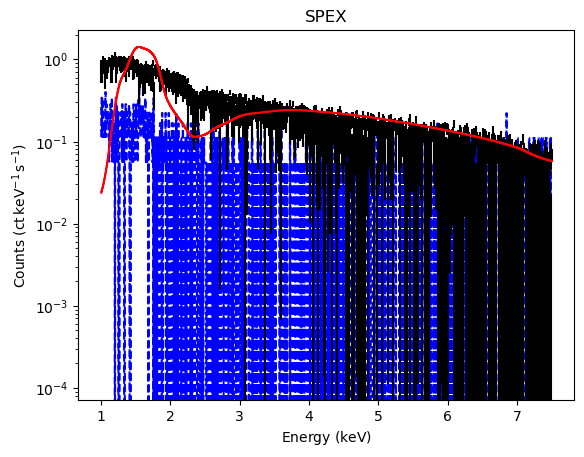

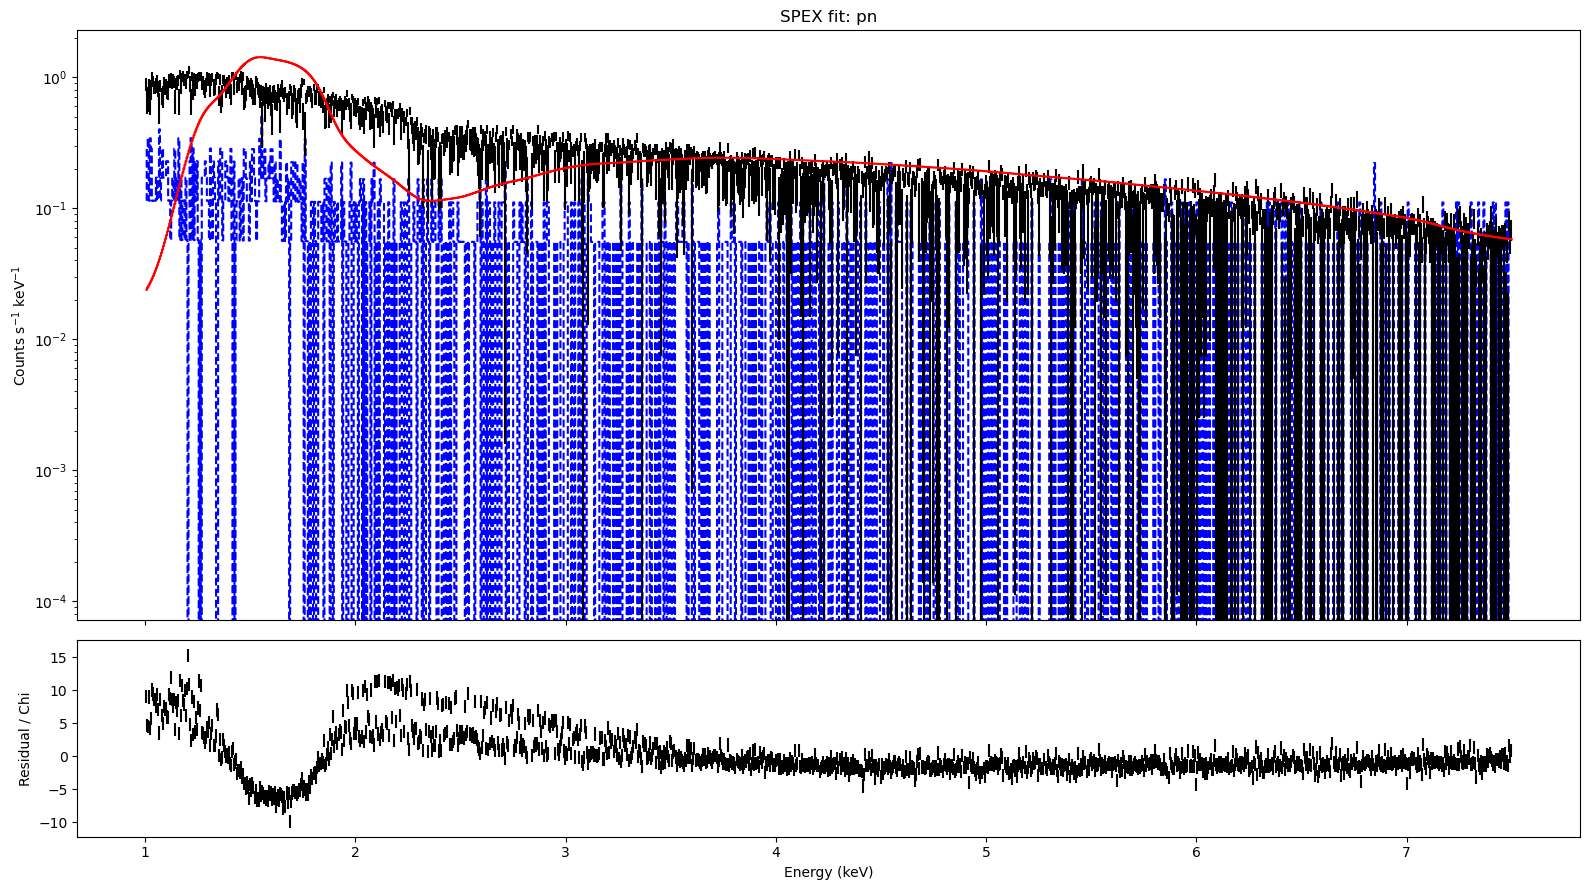

In [7]:
# --- 6. PLOTTING ---
import matplotlib.pyplot as plt
%matplotlib inline
# Get the SPEX plot manager
mgr = s.plot_data(ylog=True)

# Create the figure with a data/model panel and a residual panel
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(16, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Plot data + model on the top axis
# In your pyspex build, plot_data requires the target axis
mgr.plot_data(ax1)

# Plot chi / residuals on the bottom axis
# Different pyspex versions expose this slightly differently
if hasattr(mgr, "plot_chi"):
    try:
        mgr.plot_chi(ax2)
    except TypeError:
        # Some versions may have a different call signature
        mgr.chiplot(ax2)
elif hasattr(mgr, "chiplot"):
    mgr.chiplot(ax2)

# Styling
ax1.set_yscale("log")
ax1.set_ylabel("Counts s$^{-1}$ keV$^{-1}$")
ax1.set_title("SPEX fit: pn")
ax2.set_ylabel("Residual / Chi")
ax2.set_xlabel("Energy (keV)")

plt.tight_layout()
plt.show()

# Optional save:
# fig.savefig("../products/0865600201/pn/spec/pn_spex_fit.png", dpi=200, bbox_inches="tight")